In [1]:
# Face Recognition SDK

## Notebook 01 - Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to understand the LFW dataset before training any deep learning model.

### Tasks

- Explore the dataset structure
- Count identities
- Count images
- Analyze image properties
- Visualize sample images
- Study class distribution
- Generate dataset statistics

SyntaxError: invalid syntax (1621955869.py, line 7)

In [2]:
# ==========================================================
# Standard Library
# ==========================================================

from pathlib import Path
import os
from collections import Counter

# ==========================================================
# Data Manipulation
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# Image Processing
# ==========================================================

import cv2
from PIL import Image

# ==========================================================
# Visualization
# ==========================================================

import matplotlib.pyplot as plt

# Make plots appear inside notebook
%matplotlib inline

In [3]:
# ==========================================================
# Project Paths
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"

LFW_DIR = RAW_DATA_DIR / "lfw"

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", LFW_DIR)

Project Root : e:\Projects\FaceRecognition
Dataset Path : e:\Projects\FaceRecognition\data\raw\lfw


In [4]:
# ==========================================================
# Verify Dataset
# ==========================================================

if LFW_DIR.exists():
    print("Dataset Found")
else:
    print("Dataset NOT Found")

Dataset Found


In [5]:
# ==========================================================
# Display First 10 Identities
# ==========================================================

identities = sorted(
    [folder.name for folder in LFW_DIR.iterdir() if folder.is_dir()]
)

print(f"Total folders found: {len(identities)}\n")

print("First 10 identities:\n")

for person in identities[:10]:
    print(person)

Total folders found: 5749

First 10 identities:

AJ_Cook
AJ_Lamas
Aaron_Eckhart
Aaron_Guiel
Aaron_Patterson
Aaron_Peirsol
Aaron_Pena
Aaron_Sorkin
Aaron_Tippin
Abba_Eban


In [6]:
# ==========================================================
# Count Images Per Identity
# ==========================================================

image_counts = {}

for person_folder in LFW_DIR.iterdir():

    if person_folder.is_dir():

        num_images = len(list(person_folder.glob("*.jpg")))

        image_counts[person_folder.name] = num_images

print(f"Total identities: {len(image_counts)}")

Total identities: 5749


In [7]:
# ==========================================================
# Total Images
# ==========================================================

total_images = sum(image_counts.values())

print(f"Total Images : {total_images}")

Total Images : 13233


In [8]:
# ==========================================================
# Dataset Statistics
# ==========================================================

counts = list(image_counts.values())

print(f"Minimum Images Per Person : {min(counts)}")
print(f"Maximum Images Per Person : {max(counts)}")
print(f"Average Images Per Person : {np.mean(counts):.2f}")
print(f"Median Images Per Person  : {np.median(counts):.2f}")

Minimum Images Per Person : 1
Maximum Images Per Person : 530
Average Images Per Person : 2.30
Median Images Per Person  : 1.00


In [9]:
# ==========================================================
# Top 10 Identities
# ==========================================================

top_10 = (
    pd.DataFrame(
        image_counts.items(),
        columns=["Identity", "Images"]
    )
    .sort_values(by="Images", ascending=False)
    .head(10)
)

top_10

,Identity,Images
1870,George_W_Bush,530
1047,Colin_Powell,236
5458,Tony_Blair,144
1393,Donald_Rumsfeld,121
1891,Gerhard_Schroeder,109
370,Ariel_Sharon,77
2173,Hugo_Chavez,71
2940,Junichiro_Koizumi,60
2470,Jean_Chretien,55
2687,John_Ashcroft,53


In [10]:
# ==========================================================
# Bottom 10 Identities
# ==========================================================

bottom_10 = (
    pd.DataFrame(
        image_counts.items(),
        columns=["Identity", "Images"]
    )
    .sort_values(by="Images", ascending=True)
    .head(10)
)

bottom_10

,Identity,Images
0,Aaron_Eckhart,1
3518,Marina_Hands,1
3517,Marina_Canetti,1
3514,Marie_Haghal,1
3511,Marie-Josee_Croze,1
3510,Maribel_Dominguez,1
3509,Maria_Wetterstrand,1
3519,Marina_Kuptsova,1
3507,Maria_Simon,1
3504,Maria_Sanchez_Lorenzo,1


In [11]:
# ==========================================================
# Create Dataset Statistics DataFrame
# ==========================================================

df = pd.DataFrame(
    image_counts.items(),
    columns=["Identity", "Image_Count"]
)

df.head()

,Identity,Image_Count
0,Aaron_Eckhart,1
1,Aaron_Guiel,1
2,Aaron_Patterson,1
3,Aaron_Peirsol,4
4,Aaron_Pena,1


In [12]:
# ==========================================================
# Dataset Statistics
# ==========================================================

df.describe()

,Image_Count
count,5749.000000
mean,2.301792
std,9.016410
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,530.000000


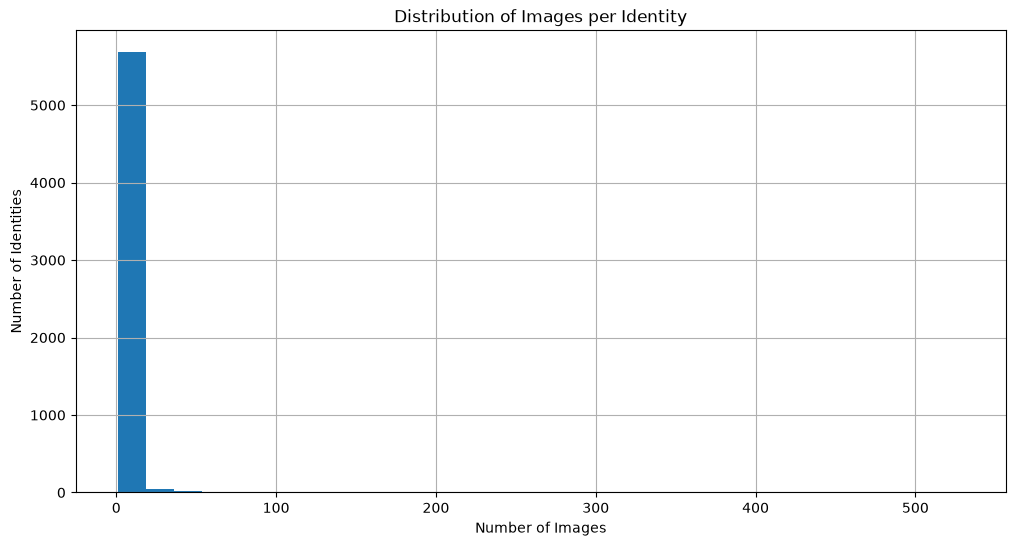

In [13]:
# ==========================================================
# Histogram of Images per Identity
# ==========================================================

plt.figure(figsize=(12,6))

plt.hist(
    df["Image_Count"],
    bins=30
)

plt.title("Distribution of Images per Identity")

plt.xlabel("Number of Images")

plt.ylabel("Number of Identities")

plt.grid(True)

plt.show()

C:\Users\DELL REGISTERED\AppData\Local\Temp\ipykernel_668\3668351146.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Image_Count"], vert=False)


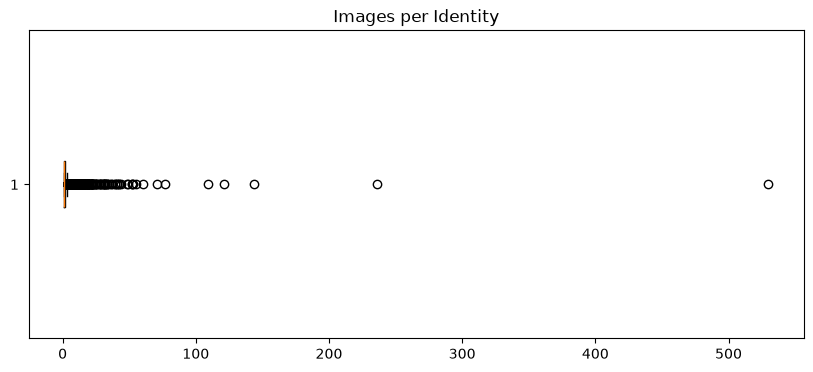

In [14]:
# ==========================================================
# Box Plot
# ==========================================================

plt.figure(figsize=(10,4))

plt.boxplot(df["Image_Count"], vert=False)

plt.title("Images per Identity")

plt.show()

In [15]:
# ==========================================================
# Identities Having Only One Image
# ==========================================================

single_image_people = df[df["Image_Count"] == 1]

print("Number of identities with only one image :", len(single_image_people))

Number of identities with only one image : 4069


In [16]:
# ==========================================================
# Images Threshold Analysis
# ==========================================================

thresholds = [2, 5, 10, 20]

for t in thresholds:
    count = (df["Image_Count"] >= t).sum()
    print(f"Identities with at least {t} images : {count}")

Identities with at least 2 images : 1680
Identities with at least 5 images : 423
Identities with at least 10 images : 158
Identities with at least 20 images : 62
